In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, auc
from sklearn.model_selection import train_test_split

from rapidgbm import RapidGBMTuner

import glob
import mplhep as hep
hep.style.use([hep.style.ATLAS])
import pickle

import uproot

In [ ]:
dataPath = '/groups/hep/kinch/data/preprocessed_data/files_from_grid/user.amoranch.Zmm_PhPy_601190_11Nov_hist/user.amoranch.42036711._000001.hist-output.root'
dataRoot = uproot.open(dataPath)

keys = dataRoot.keys()
print(keys)

tree = dataRoot['HZG_Tree']
print(tree.keys())



cutflow_tree = tree['EventInfo.cutflow']
cutflow_tree_new = tree['EventInfo.cutflow_new']


cutflow_tree = pd.DataFrame(cutflow_tree.arrays(library='pd'))
cutflow_tree_new = pd.DataFrame(cutflow_tree_new.arrays(library='pd'))


org_mask = cutflow_tree_new['EventInfo.cutflow_new']==0

print(np.sum(cutflow_tree_new==0)/len(cutflow_tree_new))
print(len(cutflow_tree))
cutflow_tree = cutflow_tree['EventInfo.cutflow'][org_mask]
print(len(cutflow_tree))
print(len(cutflow_tree_new))
cutflow_tree_new = cutflow_tree_new[cutflow_tree_new.values>0]
print(len(cutflow_tree_new))

['HZG_Tree;1', 'EventLoop_OutputStream_MxAOD;1', 'truthTree;1', 'EventLoop_FileExecuted;1', 'EventLoop_JobStats;1', 'histo_cutflow;1', 'histo_cutflow_wt;1', 'histo_cutflow_ee;1', 'histo_cutflow_eey;1', 'histo_cutflow_mumu;1', 'histo_cutflow_mumuy;1', 'histo_cutflow_ee_wt;1', 'histo_cutflow_eey_wt;1', 'histo_cutflow_mumu_wt;1', 'histo_cutflow_mumuy_wt;1', 'histo_cutflow_tautau;1', 'histo_trigger_pass;1', 'histo_trigger_pass_wt;1', 'histo_trigger_pass_match;1', 'histo_trigger_pass_match_wt;1', 'histo_trigger_denom;1', 'histo_trigger_denom_wt;1', 'histo_trigSF;1', 'cutflow_601190;1', 'cutflow_601190_w;1', 'cutflow_601190_w2;1', 'cutflow_601190_SOW;1', 'cutflow_601190_w_SOW;1', 'cutflow_601190_w2_SOW;1', 'TriggerEfficienciesPassed;1', 'TriggerEfficienciesMatched;1', 'EventLoop_RunTime;1', 'EventLoop_EventCount;1']
['Btag60_N_j', 'Btag70_N_j', 'Btag77_N_j', 'Btag85_N_j', 'Btag_N_j', 'Central_N_j', 'Central_pT_jj', 'EventInfo.PVx', 'EventInfo.PVy', 'EventInfo.PVz', 'EventInfo.actualIntPerXin

[      0.       0. 4560000. 4560000. 4560000. 4560000. 4560000. 2614713.
 2614713. 2022514. 1782553. 1782545. 1782452. 1781582.   49251.   48222.
   48222.   28151.   11434.       0.       0.       0.       0.]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
no


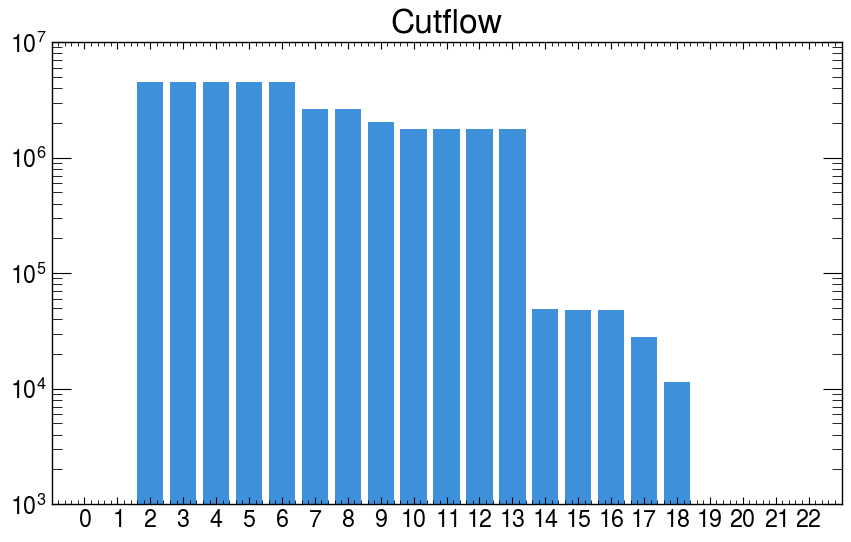

In [136]:
cutflow = dataRoot['histo_cutflow']
print(cutflow.values())

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Cutflow')
ax.bar(np.arange(len(cutflow.values())), cutflow.values())
ax.set_xticks(np.arange(len(cutflow.values())))
ax.set_xlim(-1, len(cutflow.values()))
print(np.arange(len(cutflow.values())))
ax.set_yscale('log')
print('no')

In [ ]:
print(cutflow_tree.value_counts())
print(cutflow_tree_new.value_counts())

EventInfo.cutflow
14    1732331
17      20071
18      16717
19      11434
15       1029
Name: count, dtype: int64
EventInfo.cutflow_new
16                       213031
15                        11668
18                         2110
17                         1776
19                         1088
Name: count, dtype: int64


[      0.       0. 4560000. 4560000. 4560000. 4560000. 4560000. 2614713.
 2614713. 2022514. 1782553. 1782545. 1782452. 1781582.   49251.   48222.
   48222.   28151.   11434.       0.       0.       0.       0.]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
no


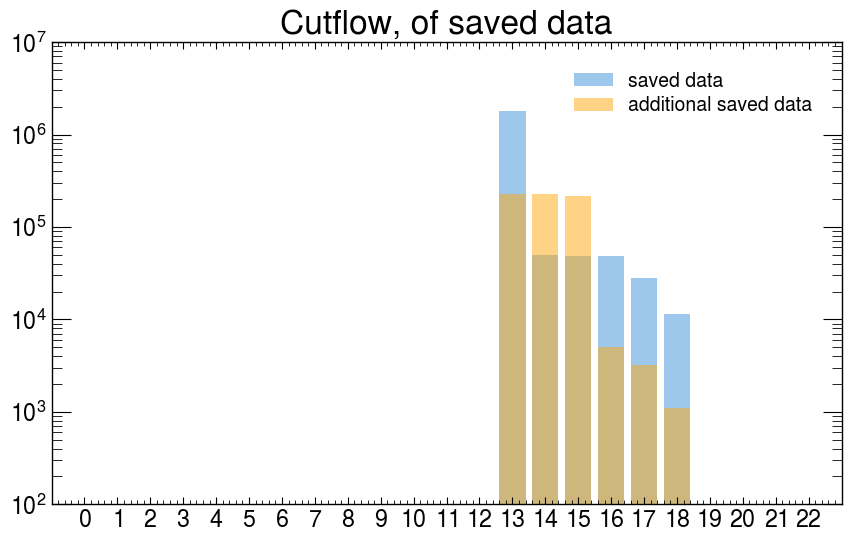

In [135]:
cutflow = dataRoot['histo_cutflow']
print(cutflow.values())


accum_cutflow = np.zeros(len(cutflow.values()))
accum_cutflow_new = np.zeros(len(cutflow.values()))

for i in range(3,23):
    if i >=14:
        accum_cutflow[i] = np.sum(cutflow_tree >= i)
        accum_cutflow_new[i] = np.sum(cutflow_tree_new >= i)

fig, ax = plt.subplots(figsize=(10, 6))
# ax.bar(np.arange(len(cutflow.values())), cutflow.values(), label='Original')
ax.set_title('Cutflow, of saved data')
ax.bar(np.arange(-1,len(cutflow.values())-1), accum_cutflow, alpha=0.5, label='saved data')
ax.bar(np.arange(-1,len(cutflow.values())-1), accum_cutflow_new, alpha=0.5, label='additional saved data')
ax.set_xticks(np.arange(len(cutflow.values())))
ax.set_xlim(-1, len(cutflow.values()))
print(np.arange(len(cutflow.values())))
ax.legend()
ax.set_yscale('log')
print('no')

1966862.0
2011255
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
no


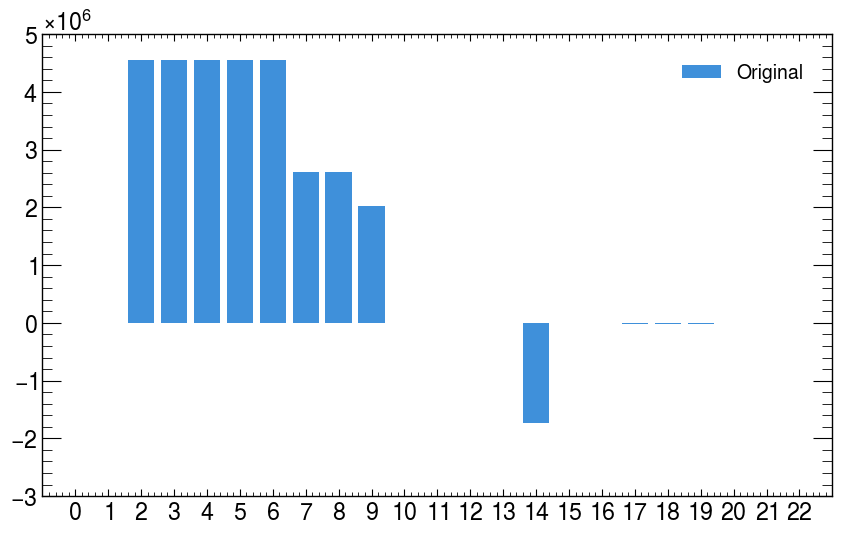

In [127]:
cutflow = dataRoot['histo_cutflow']
print(cutflow.values()[13:].sum())
print(len(org_mask))
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(np.arange(len(cutflow.values())), cutflow.values()-accum_cutflow, label='Original')
# ax.bar(np.arange(-1,len(cutflow.values())-1), accum_cutflow, alpha=0.5, label='saved data')
# ax.bar(np.arange(-1,len(cutflow.values())-1), accum_cutflow_new, alpha=0.5, label='additional saved data')
ax.set_xticks(np.arange(len(cutflow.values())))
ax.set_xlim(-1, len(cutflow.values()))
print(np.arange(len(cutflow.values())))
ax.legend()
# ax.set_yscale('log')
print('no')